# 랜덤포레스트 - 팀 공통 변수조합 5개 비교 (다영 담당)

## 팀 공통 실험 조건 (모델 4개 전부 동일하게 맞춤)

| 항목 | 값 |
|---|---|
| Train/Validation 분할 | 80:20, 시간순(랜덤 아님 — 미래정보 누수 방지) |
| 불균형 처리 | `scale_pos_weight` = 정상건수÷사기건수, **직접 계산**(하드코딩 금지) |
| 학습 중단 조건 | 100 (RF는 boosting이 아니라 "조기종료" 개념이 다름 — 아래 설명) |
| 평가지표 | PR-AUC, F1, Recall, Precision |
| 공통 임계값 | 0.90 (모델 간 비교용 — 개인 최종튜닝은 별도) |
| random seed | 42 |
| 하이퍼파라미터 | 각자 모델에 맞게 자유롭게 최적화 |

## 랜덤포레스트에서 "조기종료 100"을 어떻게 구현했나

XGBoost/LightGBM은 트리를 순서대로(부스팅) 쌓아가면서 검증 성능이 나빠지면 바로 멈출 수 있는데,
랜덤포레스트는 트리들이 서로 독립적으로 만들어지는 방식(배깅)이라 원래는 "조기종료"라는 개념이 없음.

대신 `warm_start=True`로 트리를 10개씩 늘려가면서, 매번 validation PR-AUC를 확인 →
**100그루를 더 늘려도(=10개씩 10번 연속) 최고기록을 못 갈아치우면 그 지점에서 멈추고, 제일 좋았던 트리 개수로 최종 확정**함.
XGBoost의 "100라운드 참을성"과 같은 정신을 랜덤포레스트 방식으로 옮긴 것.

## 주의 — 이번엔 3단계 분할이 아니라 80:20 2단계

팀 공통 조건이 "Train/Validation 80:20"이라, 이번엔 조기종료 판단용 데이터와 최종 성능 보고용 데이터가
**같은 validation셋**임(저번 XGBoost ver2에서 썼던 train_fit/train_val/test 3단계 분할과 다름).
이건 팀이 다 같이 합의한 공통 조건이라 그대로 따르되, "트리 개수를 정하는 데 쓴 데이터로 성능도 보고한다"는
약간의 낙관 편향 가능성은 있다는 것만 참고할 것(4명 다 똑같은 방식이라 모델 간 비교는 공정함).

## 예상 소요시간

실측 기준(변수 5개짜리 축소 테스트) 트리 190개에서 조기종료까지 약 100초 걸렸음. 실제 조합들은 변수가
더 많고(19~32개 컬럼) 5개 조합을 전부 도니까, 컴퓨터 성능에 따라 **총 10~30분 정도** 예상됨.


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import shap
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## 데이터 로드 & 시간순 80:20 분할

In [2]:
DATA_PATH = '../data/fraud_full_features.csv'

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# category 원-핫 인코딩
cat_encode_cols = [
    c for c in ['category', 'gender']
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]
_cols_before = set(df.columns)
if cat_encode_cols:
    df = pd.get_dummies(df, columns=cat_encode_cols, drop_first=False)
CAT_COLS = [c for c in df.columns if c not in _cols_before]

n = len(df)
split_idx = int(n * 0.8)
train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

print(f'train : {len(train_df):,}건 (사기 {train_df["is_fraud"].sum():,}건)')
print(f'val   : {len(val_df):,}건 (사기 {val_df["is_fraud"].sum():,}건)')
print('원-핫 category 컬럼:', CAT_COLS)


train : 1,037,340건 (사기 5,968건)
val   : 259,335건 (사기 1,538건)
원-핫 category 컬럼: ['category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


## 공통 학습 함수 (RF 전용 조기종료 구현)

`fit_rf_es`: 트리를 10개씩(`CHECK_INTERVAL`) 늘려가며 validation PR-AUC를 확인,
100그루(`PATIENCE_TREES`) 동안 최고기록 갱신이 없으면 멈추고 최고기록 지점의 트리 개수로 최종 재학습.

In [3]:
RANDOM_STATE = 42
COMMON_THRESHOLD = 0.90
CHECK_INTERVAL = 10        # 트리를 몇 개씩 늘려가며 확인할지
PATIENCE_TREES = 100       # 이만큼 트리를 더 늘려도 최고기록 못 갈아치우면 중단
MAX_TREES = 1000           # 트리 개수 상한선

RF_PARAMS = dict(
    max_depth=15,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


def fit_rf_es(feature_list, label, threshold=COMMON_THRESHOLD, verbose_log=True):
    X_train, y_train = train_df[feature_list], train_df['is_fraud']
    X_val, y_val = val_df[feature_list], val_df['is_fraud']

    normal = (y_train == 0).sum()
    fraud = (y_train == 1).sum()
    scale_pos_weight = normal / fraud
    # RandomForestClassifier에는 scale_pos_weight가 없어서 class_weight로 같은 효과를 냄
    # (정상=1배, 사기=scale_pos_weight배로 오류에 가중치를 줌 -> XGBoost의 scale_pos_weight와 동일한 의도)
    class_weight = {0: 1, 1: scale_pos_weight}

    search_model = RandomForestClassifier(
        n_estimators=CHECK_INTERVAL,
        warm_start=True,
        class_weight=class_weight,
        **RF_PARAMS,
    )

    best_pr_auc = -1.0
    best_n = CHECK_INTERVAL
    since_best = 0
    current_n = 0

    while current_n < MAX_TREES:
        current_n += CHECK_INTERVAL
        search_model.n_estimators = current_n
        search_model.fit(X_train, y_train)
        proba_val = search_model.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, proba_val)

        if pr_auc > best_pr_auc + 1e-5:
            best_pr_auc, best_n, since_best = pr_auc, current_n, 0
        else:
            since_best += CHECK_INTERVAL

        if since_best >= PATIENCE_TREES:
            break

    # 최고기록 지점의 트리 개수로 깨끗하게 재학습 (warm_start로 줄이는 건 지원 안 되므로 새로 생성)
    model = RandomForestClassifier(
        n_estimators=best_n,
        class_weight=class_weight,
        **RF_PARAMS,
    )
    model.fit(X_train, y_train)

    proba_val = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, proba_val)
    pr_auc = average_precision_score(y_val, proba_val)

    pred = (proba_val >= threshold).astype(int)
    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)

    result = {
        'label': label, 'features': list(feature_list), 'model': model,
        'n_estimators': best_n, 'scale_pos_weight': scale_pos_weight,
        'roc_auc': roc_auc, 'pr_auc': pr_auc, 'threshold': threshold,
        'precision': precision, 'recall': recall, 'f1': f1,
    }

    if verbose_log:
        print(f"[{label}] 변수 {len(feature_list)}개 | n_estimators={best_n} "
              f"(scale_pos_weight={scale_pos_weight:.2f}) | "
              f"PR-AUC={pr_auc:.4f} ROC-AUC={roc_auc:.4f} | "
              f"@{threshold:.2f} P={precision:.4f} R={recall:.4f} F1={f1:.4f}")

    return result


## 팀 공통 변수조합 5개 정의

In [4]:
TEAM_COMBOS = {
    '조합1': [
        'category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count',
        'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card',
        'prior_normal_median_amt', 'count_30min',
    ],
    '조합2': [
        'category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count',
        'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card',
        'prior_normal_median_amt', 'count_30min', 'merchant_change_count',
    ],
    '조합3': [
        'category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count',
        'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card',
        'prior_normal_median_amt', 'count_30min', 'high_speed',
    ],
    '조합4': [
        'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category',
        'amt', 'trans_hour', 'age',
    ],
    '조합5': [
        'category', 'amt', 'is_online', 'recent_24h_high_amt_count',
        'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt',
        'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card',
        'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1h',
        'prior_normal_median_amt', 'amt_to_prior_median_ratio', 'risk_time_22_04',
        'interact_repeat_category', 'has_prior_normal_transaction',
    ],
}


def expand_features(unit_names):
    # 'category'는 원-핫 14개 컬럼으로, 나머지는 그대로 1개 컬럼으로 펼침
    feats = []
    for name in unit_names:
        if name == 'category':
            feats.extend(CAT_COLS)
        else:
            feats.append(name)
    return feats


# 실제 데이터셋에 없는 컬럼이 있는지 사전 확인
for combo_name, units in TEAM_COMBOS.items():
    feats = expand_features(units)
    missing = [f for f in feats if f not in df.columns]
    if missing:
        print(f'[경고] {combo_name}: 데이터셋에 없는 컬럼 {missing}')
    else:
        print(f'{combo_name}: 변수 {len(units)}개 단위 -> 실제 컬럼 {len(feats)}개 (OK)')


조합1: 변수 10개 단위 -> 실제 컬럼 23개 (OK)
조합2: 변수 11개 단위 -> 실제 컬럼 24개 (OK)
조합3: 변수 11개 단위 -> 실제 컬럼 24개 (OK)
조합4: 변수 6개 단위 -> 실제 컬럼 19개 (OK)
조합5: 변수 19개 단위 -> 실제 컬럼 32개 (OK)


## 5개 조합 전부 학습 & 비교

In [5]:
print('=== 팀 공통 변수조합 5개 학습 (조기종료 트리 개수 자동 결정) ===\n')

combo_results = {}
for combo_name, units in TEAM_COMBOS.items():
    feats = expand_features(units)
    combo_results[combo_name] = fit_rf_es(feats, combo_name)

print('\n=== 비교 요약표 (PR-AUC 내림차순) ===')
summary = pd.DataFrame([
    {
        '조합': name, '변수단위수': len(TEAM_COMBOS[name]), '실제컬럼수': len(r['features']),
        'n_estimators': r['n_estimators'], 'PR-AUC': round(r['pr_auc'], 4),
        'ROC-AUC': round(r['roc_auc'], 4), 'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4), 'F1': round(r['f1'], 4),
    }
    for name, r in combo_results.items()
]).sort_values('PR-AUC', ascending=False)
print(summary.to_string(index=False))

best_combo_name = summary.iloc[0]['조합']
print(f"\n>> PR-AUC 기준 최고 조합: {best_combo_name}")


=== 팀 공통 변수조합 5개 학습 (조기종료 트리 개수 자동 결정) ===

[조합1] 변수 23개 | n_estimators=740 (scale_pos_weight=172.82) | PR-AUC=0.9606 ROC-AUC=0.9992 | @0.90 P=0.9299 R=0.8882 F1=0.9085
[조합2] 변수 24개 | n_estimators=160 (scale_pos_weight=172.82) | PR-AUC=0.9608 ROC-AUC=0.9992 | @0.90 P=0.9305 R=0.8875 F1=0.9085
[조합3] 변수 24개 | n_estimators=240 (scale_pos_weight=172.82) | PR-AUC=0.9606 ROC-AUC=0.9992 | @0.90 P=0.9285 R=0.8869 F1=0.9072
[조합4] 변수 19개 | n_estimators=90 (scale_pos_weight=172.82) | PR-AUC=0.9635 ROC-AUC=0.9992 | @0.90 P=0.9170 R=0.9122 F1=0.9146
[조합5] 변수 32개 | n_estimators=360 (scale_pos_weight=172.82) | PR-AUC=0.9561 ROC-AUC=0.9990 | @0.90 P=0.9619 R=0.8218 F1=0.8864

=== 비교 요약표 (PR-AUC 내림차순) ===
 조합  변수단위수  실제컬럼수  n_estimators  PR-AUC  ROC-AUC  Precision  Recall     F1
조합4      6     19            90  0.9635   0.9992     0.9170  0.9122 0.9146
조합2     11     24           160  0.9608   0.9992     0.9305  0.8875 0.9085
조합1     10     23           740  0.9606   0.9992     0.9299  0.8882 0.9085
조합

## 최고 조합 상세 리포트 — Confusion Matrix & Feature Importances

In [6]:
best_result = combo_results[best_combo_name]
best_model = best_result['model']
best_feats = best_result['features']

X_val_best = val_df[best_feats]
y_val = val_df['is_fraud']
proba_best = best_model.predict_proba(X_val_best)[:, 1]
pred_best = (proba_best >= COMMON_THRESHOLD).astype(int)

print(f'=== {best_combo_name} Confusion Matrix (threshold={COMMON_THRESHOLD}) ===')
cm = confusion_matrix(y_val, pred_best)
print(pd.DataFrame(cm, index=['실제_정상', '실제_사기'], columns=['예측_정상', '예측_사기']))

print(f"\nPrecision={best_result['precision']:.4f}  Recall={best_result['recall']:.4f}  "
      f"F1={best_result['f1']:.4f}  n_estimators={best_result['n_estimators']}")

importances = pd.Series(
    best_model.feature_importances_, index=best_feats
).sort_values(ascending=False)
print('\n=== Feature Importances (상위 15개) ===')
print(importances.head(15))


=== 조합4 Confusion Matrix (threshold=0.9) ===
        예측_정상  예측_사기
실제_정상  257670    127
실제_사기     135   1403

Precision=0.9170  Recall=0.9122  F1=0.9146  n_estimators=90

=== Feature Importances (상위 15개) ===
amt                          0.316871
recent_24h_high_amt_count    0.251151
amt_to_prior_median_ratio    0.237128
trans_hour                   0.087471
category_gas_transport       0.029003
age                          0.012495
category_grocery_pos         0.011493
category_shopping_net        0.010109
category_grocery_net         0.006165
category_food_dining         0.006147
category_shopping_pos        0.005227
category_home                0.004913
category_misc_pos            0.004306
category_travel              0.004291
category_entertainment       0.003578
dtype: float64


## 전체 조합 Confusion Matrix (팀 제출용)

In [7]:
print('=== 조합별 Confusion Matrix 전부 (threshold=0.90) ===\n')
for combo_name, r in combo_results.items():
    model = r['model']
    feats = r['features']
    proba = model.predict_proba(val_df[feats])[:, 1]
    pred = (proba >= COMMON_THRESHOLD).astype(int)
    cm = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f'--- {combo_name} (변수 {len(TEAM_COMBOS[combo_name])}개, PR-AUC {r["pr_auc"]:.4f}) ---')
    print(pd.DataFrame(cm, index=['실제_정상', '실제_사기'], columns=['예측_정상', '예측_사기']))
    print(f'잡은사기={tp}  놓친사기={fn}  오탐={fp}\n')


=== 조합별 Confusion Matrix 전부 (threshold=0.90) ===

--- 조합1 (변수 10개, PR-AUC 0.9606) ---
        예측_정상  예측_사기
실제_정상  257694    103
실제_사기     172   1366
잡은사기=1366  놓친사기=172  오탐=103

--- 조합2 (변수 11개, PR-AUC 0.9608) ---
        예측_정상  예측_사기
실제_정상  257695    102
실제_사기     173   1365
잡은사기=1365  놓친사기=173  오탐=102

--- 조합3 (변수 11개, PR-AUC 0.9606) ---
        예측_정상  예측_사기
실제_정상  257692    105
실제_사기     174   1364
잡은사기=1364  놓친사기=174  오탐=105

--- 조합4 (변수 6개, PR-AUC 0.9635) ---
        예측_정상  예측_사기
실제_정상  257670    127
실제_사기     135   1403
잡은사기=1403  놓친사기=135  오탐=127

--- 조합5 (변수 19개, PR-AUC 0.9561) ---
        예측_정상  예측_사기
실제_정상  257747     50
실제_사기     274   1264
잡은사기=1264  놓친사기=274  오탐=50



## (보너스) 최고 조합 SHAP 해석

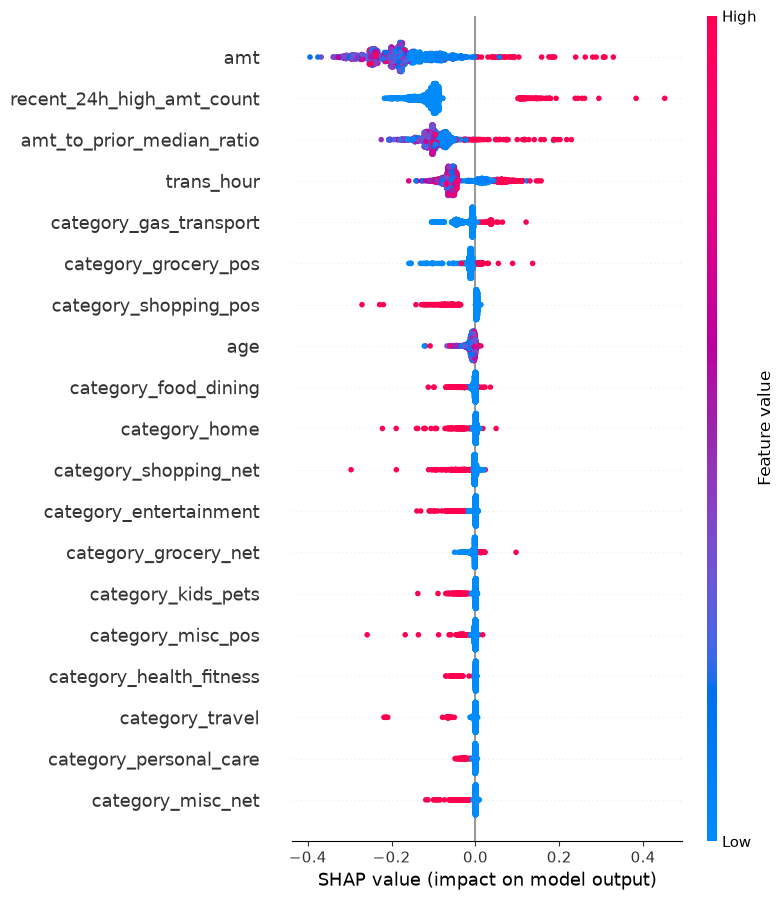

In [8]:
explainer = shap.TreeExplainer(best_model)
X_val_sample = val_df[best_feats].sample(min(2000, len(val_df)), random_state=RANDOM_STATE)
shap_values = explainer(X_val_sample, check_additivity=False)

# RandomForest는 이진분류일 때 shap_values가 (samples, features, 2)로 나올 수 있음 -> 사기(class 1)만 사용
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_val_sample, show=True)


## 2. 시간순 교차검증 & 하이퍼파라미터 튜닝

민정님 LightGBM 분석과 같은 구조로 진행함 — 전체 기간을 6등분해서 3-Fold 시간순(확장형) 교차검증을 함:
Fold1(앞 3/6 학습→4번째 구간 검증), Fold2(앞 4/6→5번째), Fold3(앞 5/6→6번째). 매 fold마다 train이 시간상 val보다 항상 앞서서 미래정보 누수가 없음.

1차 조합비교에서 1등이었던 **조합4**를 대상으로, 하이퍼파라미터(max_depth, min_samples_leaf)를 튜닝함.
1차 기준: 3-Fold 평균 PR-AUC가 높은 설정 / 2차 기준(동점 시): Fold별 PR-AUC 표준편차가 작은(안정적인) 설정.

In [9]:
## 시간순 3-Fold 경계 생성 (민정님 방식과 동일 - 6구간, 확장형 3-Fold)
TIME_COL = 'trans_date_trans_time'

boundaries = np.linspace(0, len(df), 7, dtype=int)
time_folds = []
for fold_number in range(1, 4):
    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]
    fold_train = df.iloc[0:train_end]
    fold_val = df.iloc[val_start:val_end]
    time_folds.append({'fold': fold_number, 'train': fold_train, 'val': fold_val})

    print(f'=== Fold {fold_number} ===')
    print(f"Train 기간: {fold_train[TIME_COL].min()} ~ {fold_train[TIME_COL].max()} "
          f"({len(fold_train):,}건, 사기 {int(fold_train['is_fraud'].sum()):,}건)")
    print(f"Val   기간: {fold_val[TIME_COL].min()} ~ {fold_val[TIME_COL].max()} "
          f"({len(fold_val):,}건, 사기 {int(fold_val['is_fraud'].sum()):,}건)")
    print(f"시간 순서 정상: {fold_train[TIME_COL].max() <= fold_val[TIME_COL].min()}\n")


=== Fold 1 ===
Train 기간: 2019-01-01 00:00:18 ~ 2019-10-03 07:35:11 (648,337건, 사기 3,827건)
Val   기간: 2019-10-03 07:35:47 ~ 2019-12-18 17:06:47 (216,113건, 사기 1,091건)
시간 순서 정상: True

=== Fold 2 ===
Train 기간: 2019-01-01 00:00:18 ~ 2019-12-18 17:06:47 (864,450건, 사기 4,918건)
Val   기간: 2019-12-18 17:07:05 ~ 2020-03-24 15:14:25 (216,112건, 사기 1,363건)
시간 순서 정상: True

=== Fold 3 ===
Train 기간: 2019-01-01 00:00:18 ~ 2020-03-24 15:14:25 (1,080,562건, 사기 6,281건)
Val   기간: 2020-03-24 15:14:30 ~ 2020-06-21 12:13:37 (216,113건, 사기 1,225건)
시간 순서 정상: True



## 5개 조합 전부 시간순 3-Fold 교차검증

1차 비교(80:20 한 번 나눈 결과)에서는 조합4가 1등이었는데, 이게 우연한 결과인지 확인하기 위해 5개 조합 전부를 방금 만든 3개 시간순 Fold에 똑같이 돌려봄. 하이퍼파라미터는 1차 비교와 동일한 기본값(max_depth=15, min_samples_leaf=10) 사용, n_estimators는 100으로 고정해서 속도 확보.

In [10]:
print('=== 5개 조합 전부 시간순 3-Fold 교차검증 ===\n')

all_combo_cv_rows = []
for combo_name, units in TEAM_COMBOS.items():
    feats = expand_features(units)
    fold_pr_aucs = []
    for tf in time_folds:
        X_tr, y_tr = tf['train'][feats], tf['train']['is_fraud']
        X_va, y_va = tf['val'][feats], tf['val']['is_fraud']
        spw = (y_tr == 0).sum() / (y_tr == 1).sum()

        m = RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_leaf=10,
            min_samples_split=20, max_features='sqrt',
            class_weight={0: 1, 1: spw}, random_state=RANDOM_STATE, n_jobs=-1,
        )
        m.fit(X_tr, y_tr)
        proba = m.predict_proba(X_va)[:, 1]
        fold_pr_aucs.append(average_precision_score(y_va, proba))

    mean_pr = float(np.mean(fold_pr_aucs))
    std_pr = float(np.std(fold_pr_aucs))
    single_split_pr = combo_results[combo_name]['pr_auc']
    print(f'{combo_name}: fold별 PR-AUC={[round(x,4) for x in fold_pr_aucs]}  '
          f'평균={mean_pr:.4f}  표준편차={std_pr:.4f}  (1차 단일분할 PR-AUC={single_split_pr:.4f})')
    all_combo_cv_rows.append({
        '조합': combo_name, '변수개수': len(units),
        'fold1_pr_auc': round(fold_pr_aucs[0], 4), 'fold2_pr_auc': round(fold_pr_aucs[1], 4),
        'fold3_pr_auc': round(fold_pr_aucs[2], 4), '교차검증_평균': round(mean_pr, 4),
        '교차검증_표준편차': round(std_pr, 4), '1차_단일분할': round(single_split_pr, 4),
    })

all_combo_cv_df = pd.DataFrame(all_combo_cv_rows).sort_values('교차검증_평균', ascending=False)
print('\n=== 5개 조합 교차검증 순위 (평균 PR-AUC 내림차순) ===')
print(all_combo_cv_df.to_string(index=False))

cv_winner = all_combo_cv_df.iloc[0]['조합']
print(f"\n>> 교차검증 기준 1등: {cv_winner}")
if cv_winner == '조합4':
    print('   -> 1차 비교(단일분할)와 같은 결과 -> 조합4가 우연이 아니라 안정적으로 1등')
else:
    print(f'   -> 1차 비교(단일분할)에서는 조합4가 1등이었는데, 교차검증에서는 순위가 바뀜 -> 재검토 필요')


=== 5개 조합 전부 시간순 3-Fold 교차검증 ===

조합1: fold별 PR-AUC=[0.943, 0.9565, 0.959]  평균=0.9528  표준편차=0.0070  (1차 단일분할 PR-AUC=0.9606)
조합2: fold별 PR-AUC=[0.9443, 0.9554, 0.9565]  평균=0.9520  표준편차=0.0055  (1차 단일분할 PR-AUC=0.9608)
조합3: fold별 PR-AUC=[0.9424, 0.9569, 0.9593]  평균=0.9529  표준편차=0.0075  (1차 단일분할 PR-AUC=0.9606)
조합4: fold별 PR-AUC=[0.9509, 0.9609, 0.9622]  평균=0.9580  표준편차=0.0051  (1차 단일분할 PR-AUC=0.9635)
조합5: fold별 PR-AUC=[0.9447, 0.9445, 0.9546]  평균=0.9479  표준편차=0.0047  (1차 단일분할 PR-AUC=0.9561)

=== 5개 조합 교차검증 순위 (평균 PR-AUC 내림차순) ===
 조합  변수개수  fold1_pr_auc  fold2_pr_auc  fold3_pr_auc  교차검증_평균  교차검증_표준편차  1차_단일분할
조합4     6        0.9509        0.9609        0.9622   0.9580     0.0051   0.9635
조합3    11        0.9424        0.9569        0.9593   0.9529     0.0075   0.9606
조합1    10        0.9430        0.9565        0.9590   0.9528     0.0070   0.9606
조합2    11        0.9443        0.9554        0.9565   0.9520     0.0055   0.9608
조합5    19        0.9447        0.9445        0.9546   0.9479   

## 하이퍼파라미터 그리드 탐색 (1차 - n_estimators는 100으로 고정해서 빠르게 비교)

`max_depth` x `min_samples_leaf` 조합 9가지 x 3개 fold = 27번 학습. 이 단계에서는 트리 개수를 정확히 조기종료로 찾지 않고 100개로 고정해서 속도를 확보하고, 제일 좋은 하이퍼파라미터 조합을 먼저 찾은 뒤 마지막에 그 설정으로만 정밀 조기종료 탐색을 함.

In [11]:
COMBO4_FEATURES = combo_results['조합4']['features']

param_grid = {
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
}

grid_rows = []
for max_depth in param_grid['max_depth']:
    for min_samples_leaf in param_grid['min_samples_leaf']:
        fold_pr_aucs = []
        for tf in time_folds:
            X_tr, y_tr = tf['train'][COMBO4_FEATURES], tf['train']['is_fraud']
            X_va, y_va = tf['val'][COMBO4_FEATURES], tf['val']['is_fraud']
            spw = (y_tr == 0).sum() / (y_tr == 1).sum()

            m = RandomForestClassifier(
                n_estimators=100, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                min_samples_split=20, max_features='sqrt',
                class_weight={0: 1, 1: spw}, random_state=RANDOM_STATE, n_jobs=-1,
            )
            m.fit(X_tr, y_tr)
            proba = m.predict_proba(X_va)[:, 1]
            fold_pr_aucs.append(average_precision_score(y_va, proba))

        mean_pr = float(np.mean(fold_pr_aucs))
        std_pr = float(np.std(fold_pr_aucs))
        print(f'max_depth={max_depth:>3}  min_samples_leaf={min_samples_leaf:>3}  '
              f'fold별 PR-AUC={[round(x,4) for x in fold_pr_aucs]}  평균={mean_pr:.4f}  표준편차={std_pr:.4f}')
        grid_rows.append({
            'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf,
            'fold1_pr_auc': round(fold_pr_aucs[0], 4), 'fold2_pr_auc': round(fold_pr_aucs[1], 4),
            'fold3_pr_auc': round(fold_pr_aucs[2], 4), 'mean_pr_auc': round(mean_pr, 4),
            'std_pr_auc': round(std_pr, 4),
        })

grid_df = pd.DataFrame(grid_rows).sort_values(['mean_pr_auc', 'std_pr_auc'], ascending=[False, True])
print('\n=== 그리드 결과 (평균 PR-AUC 내림차순, 동점시 표준편차 오름차순) ===')
print(grid_df.to_string(index=False))

best_params = grid_df.iloc[0]
BEST_MAX_DEPTH = int(best_params['max_depth'])
BEST_MIN_SAMPLES_LEAF = int(best_params['min_samples_leaf'])
print(f"\n>> 최종 채택: max_depth={BEST_MAX_DEPTH}, min_samples_leaf={BEST_MIN_SAMPLES_LEAF} "
      f"(평균 PR-AUC={best_params['mean_pr_auc']:.4f}, 표준편차={best_params['std_pr_auc']:.4f})")


max_depth= 10  min_samples_leaf=  5  fold별 PR-AUC=[0.9284, 0.9416, 0.945]  평균=0.9383  표준편차=0.0072
max_depth= 10  min_samples_leaf= 10  fold별 PR-AUC=[0.9286, 0.9415, 0.9412]  평균=0.9371  표준편차=0.0060
max_depth= 10  min_samples_leaf= 20  fold별 PR-AUC=[0.9252, 0.9383, 0.9437]  평균=0.9357  표준편차=0.0078
max_depth= 15  min_samples_leaf=  5  fold별 PR-AUC=[0.9514, 0.9621, 0.9625]  평균=0.9587  표준편차=0.0051
max_depth= 15  min_samples_leaf= 10  fold별 PR-AUC=[0.9509, 0.9609, 0.9622]  평균=0.9580  표준편차=0.0051
max_depth= 15  min_samples_leaf= 20  fold별 PR-AUC=[0.9462, 0.9581, 0.9613]  평균=0.9552  표준편차=0.0065
max_depth= 20  min_samples_leaf=  5  fold별 PR-AUC=[0.9541, 0.9663, 0.9654]  평균=0.9619  표준편차=0.0055
max_depth= 20  min_samples_leaf= 10  fold별 PR-AUC=[0.9517, 0.9632, 0.9651]  평균=0.9600  표준편차=0.0059
max_depth= 20  min_samples_leaf= 20  fold별 PR-AUC=[0.9483, 0.9612, 0.9618]  평균=0.9571  표준편차=0.0062

=== 그리드 결과 (평균 PR-AUC 내림차순, 동점시 표준편차 오름차순) ===
 max_depth  min_samples_leaf  fold1_pr_auc  fold2_pr_auc  fold

## 최종 모델 - 채택된 하이퍼파라미터로 정밀 조기종료 재탐색

위에서 찾은 최적 하이퍼파라미터를 원래의 80:20 train/val 분할(조기종료 판단용)에 적용해서, 트리 개수도 (100 고정이 아니라) 조기종료로 다시 정확하게 찾음 - 최종 제출용 모델.

In [12]:
RF_PARAMS_TUNED = dict(
    max_depth=BEST_MAX_DEPTH,
    min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
    min_samples_split=20,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


def fit_rf_es_tuned(feature_list, label, threshold=COMMON_THRESHOLD):
    X_train, y_train = train_df[feature_list], train_df['is_fraud']
    X_val, y_val = val_df[feature_list], val_df['is_fraud']
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    class_weight = {0: 1, 1: scale_pos_weight}

    search_model = RandomForestClassifier(
        n_estimators=CHECK_INTERVAL, warm_start=True, class_weight=class_weight, **RF_PARAMS_TUNED,
    )
    best_pr_auc, best_n, since_best, current_n = -1.0, CHECK_INTERVAL, 0, 0
    while current_n < MAX_TREES:
        current_n += CHECK_INTERVAL
        search_model.n_estimators = current_n
        search_model.fit(X_train, y_train)
        proba_val = search_model.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, proba_val)
        if pr_auc > best_pr_auc + 1e-5:
            best_pr_auc, best_n, since_best = pr_auc, current_n, 0
        else:
            since_best += CHECK_INTERVAL
        if since_best >= PATIENCE_TREES:
            break

    model = RandomForestClassifier(n_estimators=best_n, class_weight=class_weight, **RF_PARAMS_TUNED)
    model.fit(X_train, y_train)

    proba_val = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, proba_val)
    pr_auc = average_precision_score(y_val, proba_val)
    pred = (proba_val >= threshold).astype(int)
    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)

    print(f"[{label}] 변수 {len(feature_list)}개 | n_estimators={best_n} | "
          f"max_depth={BEST_MAX_DEPTH} min_samples_leaf={BEST_MIN_SAMPLES_LEAF} | "
          f"PR-AUC={pr_auc:.4f} ROC-AUC={roc_auc:.4f} | "
          f"@{threshold:.2f} P={precision:.4f} R={recall:.4f} F1={f1:.4f}")

    return {
        'label': label, 'features': list(feature_list), 'model': model, 'n_estimators': best_n,
        'roc_auc': roc_auc, 'pr_auc': pr_auc, 'precision': precision, 'recall': recall, 'f1': f1,
    }


tuned_result = fit_rf_es_tuned(COMBO4_FEATURES, '조합4_튜닝후')

print('\n=== 튜닝 전(기본 하이퍼파라미터) vs 튜닝 후 비교 ===')
before = combo_results['조합4']
print(f"튜닝 전: max_depth=15 min_samples_leaf=10 | n_estimators={before['n_estimators']} | "
      f"PR-AUC={before['pr_auc']:.4f} F1={before['f1']:.4f}")
print(f"튜닝 후: max_depth={BEST_MAX_DEPTH} min_samples_leaf={BEST_MIN_SAMPLES_LEAF} | "
      f"n_estimators={tuned_result['n_estimators']} | PR-AUC={tuned_result['pr_auc']:.4f} F1={tuned_result['f1']:.4f}")


[조합4_튜닝후] 변수 19개 | n_estimators=210 | max_depth=20 min_samples_leaf=5 | PR-AUC=0.9660 ROC-AUC=0.9992 | @0.90 P=0.9405 R=0.9038 F1=0.9218

=== 튜닝 전(기본 하이퍼파라미터) vs 튜닝 후 비교 ===
튜닝 전: max_depth=15 min_samples_leaf=10 | n_estimators=90 | PR-AUC=0.9635 F1=0.9146
튜닝 후: max_depth=20 min_samples_leaf=5 | n_estimators=210 | PR-AUC=0.9660 F1=0.9218


## 3. 모델별 임계값 조정 및 성능 비교 (팀 공식 3단계)

튜닝이 끝난 조합4(max_depth=20, min_samples_leaf=5)로 시간순 3-Fold를 다시 학습하면서, 이번엔 각 Fold의 Validation 예측확률과 실제값을 그대로 저장함. 그리드서치 때는 PR-AUC 점수만 봤지만, 이제는 F1 최대 임계값을 찾기 위해 예측값 자체가 필요하기 때문.

In [ ]:
oof_true = []
oof_proba = []
fold_models = []

print('=== 조합4 최적 하이퍼파라미터(max_depth=20, min_samples_leaf=5)로 Fold별 재학습 ===\n')

for tf in time_folds:
    X_tr = tf['train'][COMBO4_FEATURES]
    y_tr = tf['train']['is_fraud']
    X_va = tf['val'][COMBO4_FEATURES]
    y_va = tf['val']['is_fraud']

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    # 그리드서치 때처럼 n_estimators=100 고정이 아니라, 이번엔 fold별로 조기종료까지 정확히 재탐색
    search_model = RandomForestClassifier(
        n_estimators=CHECK_INTERVAL, warm_start=True, class_weight={0: 1, 1: spw},
        max_depth=BEST_MAX_DEPTH, min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
        min_samples_split=20, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1,
    )
    best_pr_auc, best_n, since_best, current_n = -1.0, CHECK_INTERVAL, 0, 0
    while current_n < MAX_TREES:
        current_n += CHECK_INTERVAL
        search_model.n_estimators = current_n
        search_model.fit(X_tr, y_tr)
        proba = search_model.predict_proba(X_va)[:, 1]
        pr_auc = average_precision_score(y_va, proba)
        if pr_auc > best_pr_auc + 1e-5:
            best_pr_auc, best_n, since_best = pr_auc, current_n, 0
        else:
            since_best += CHECK_INTERVAL
        if since_best >= PATIENCE_TREES:
            break

    fold_model = RandomForestClassifier(
        n_estimators=best_n, class_weight={0: 1, 1: spw},
        max_depth=BEST_MAX_DEPTH, min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
        min_samples_split=20, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1,
    )
    fold_model.fit(X_tr, y_tr)
    proba_val = fold_model.predict_proba(X_va)[:, 1]
    fold_pr_auc = average_precision_score(y_va, proba_val)

    print(f"Fold {tf['fold']} | n_estimators={best_n} | PR-AUC={fold_pr_auc:.6f} | "
          f"Val 건수={len(y_va):,} (사기 {int(y_va.sum()):,}건)")

    oof_true.extend(y_va.to_numpy())
    oof_proba.extend(proba_val)
    fold_models.append(fold_model)

oof_true = np.array(oof_true)
oof_proba = np.array(oof_proba)
print(f"\nOOF 통합 검증 건수: {len(oof_true):,} (사기 {int(oof_true.sum()):,}건)")


## OOF 통합 → F1 최대 임계값 탐색 → 최적 임계값에서 최종 성능

In [ ]:
from sklearn.metrics import precision_recall_curve

oof_pr_auc = average_precision_score(oof_true, oof_proba)

precisions, recalls, thresholds = precision_recall_curve(oof_true, oof_proba)
p, r = precisions[:-1], recalls[:-1]
denom = p + r
f1_scores = np.divide(2 * p * r, denom, out=np.zeros_like(denom), where=denom != 0)

best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])

oof_pred = (oof_proba >= best_threshold).astype(int)
final_precision = precision_score(oof_true, oof_pred, zero_division=0)
final_recall = recall_score(oof_true, oof_pred, zero_division=0)
final_f1 = f1_score(oof_true, oof_pred, zero_division=0)
cm = confusion_matrix(oof_true, oof_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print('=' * 60)
print('조합4 (max_depth=20, min_samples_leaf=5) — OOF 최종 성능')
print('=' * 60)
print(f'OOF PR-AUC       : {oof_pr_auc:.6f}')
print(f'F1 최대 임계값   : {best_threshold:.6f}')
print(f'Precision        : {final_precision:.6f}')
print(f'Recall           : {final_recall:.6f}')
print(f'F1               : {final_f1:.6f}')
print()
print('Confusion Matrix')
print(cm)
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print()
print(f"참고 — 팀 공통 임계값 0.90 기준(cell23, 단일 80:20): "
      f"PR-AUC=0.9660 P=0.9405 R=0.9038 F1=0.9218")
